# Prediksi Risiko Prediabetes Berdasarkan Faktor Klinis dan Gaya Hidup Menggunakan XGBoost

Notebook ini berisi dua pendekatan pemodelan yang perlu dibedakan secara metodologis:

1. **Model Prediabetes asli**, yaitu model binary classification untuk memprediksi target asli `Prediabetes` dari dataset.
2. **Model Risk_Level**, yaitu model multiclass classification yang menggunakan target buatan berbasis sistem scoring faktor risiko.

Pendekatan pertama dievaluasi secara jujur menggunakan baseline, classification report, ROC-AUC, PR-AUC, dan confusion matrix. Pendekatan kedua digunakan sebagai sistem klasifikasi risiko berbasis scoring, bukan sebagai model diagnosis medis.

---
### Ringkasan Keputusan
| Item | Keputusan |
|---|---|
| **Target asli** | `Prediabetes` (Yes/No) |
| **Target tambahan** | `Risk_Level` berbasis scoring |
| **Algoritma utama** | XGBoost |
| **Faktor yang digunakan** | Faktor klinis, genetik, dan gaya hidup |
| **Catatan metodologis** | `Risk_Level` adalah target buatan, bukan label klinis asli |

### Fitur Utama yang Digunakan
`Age`, `BMI`, `HbA1c`, `Fasting_Blood_Sugar`, `Genetic_Risk_Score`, `Family_History_Diabetes`, `Physical_Activity_Level`, `Dietary_Habits`, `Smoking`, `Alcohol_Consumption`, `Sleep_Hours`, `Stress_Level`

### Catatan Penting
Hasil model pada notebook ini tidak boleh ditafsirkan sebagai diagnosis medis. Prediksi hanya digunakan untuk analisis data dan estimasi risiko awal.

---
## STEP 0 — Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


---
## STEP 1 — Load Dataset

In [4]:
# df = pd.read_csv('diabetes_young_adults_india.csv')
file_path = "../data/diabetes_young_adults_india.csv"
df = pd.read_csv(file_path)

print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Shape dataset: (100000, 22)
Jumlah baris  : 100,000
Jumlah kolom  : 22


,ID,Age,Gender,Region,Family_Income,Family_History_Diabetes,Parent_Diabetes_Type,Genetic_Risk_Score,BMI,Physical_Activity_Level,...,Smoking,Alcohol_Consumption,Fasting_Blood_Sugar,HbA1c,Cholesterol_Level,Prediabetes,Diabetes_Type,Sleep_Hours,Stress_Level,Screen_Time
0,1,21,Male,North,2209393,No,NaN,6,31.4,Sedentary,...,Yes,No,95.6,9.5,163.3,Yes,NaN,7.7,7,6.8
1,2,18,Female,Central,387650,No,NaN,5,24.4,Active,...,No,No,164.9,5.0,169.1,Yes,NaN,7.9,8,6.0
2,3,25,Male,North,383333,No,NaN,6,20.0,Moderate,...,No,No,110.5,8.3,296.3,Yes,Type 1,7.6,8,4.6
3,4,22,Male,Northeast,2443733,No,NaN,4,39.8,Moderate,...,No,Yes,160.7,4.6,252.8,No,NaN,9.5,2,10.9
4,5,19,Male,Central,1449463,No,NaN,4,19.2,Moderate,...,No,Yes,73.7,5.3,252.3,No,NaN,6.4,2,1.3


In [5]:
# Cek tipe data semua kolom
df.dtypes

ID                           int64
Age                          int64
Gender                         str
Region                         str
Family_Income                int64
Family_History_Diabetes        str
Parent_Diabetes_Type           str
Genetic_Risk_Score           int64
BMI                        float64
Physical_Activity_Level        str
Dietary_Habits                 str
Fast_Food_Intake             int64
Smoking                        str
Alcohol_Consumption            str
Fasting_Blood_Sugar        float64
HbA1c                      float64
Cholesterol_Level          float64
Prediabetes                    str
Diabetes_Type                  str
Sleep_Hours                float64
Stress_Level                 int64
Screen_Time                float64
dtype: object

In [6]:
# Cek missing value
print('Missing values per kolom:')
print(df.isnull().sum())

Missing values per kolom:
ID                             0
Age                            0
Gender                         0
Region                         0
Family_Income                  0
Family_History_Diabetes        0
Parent_Diabetes_Type       65097
Genetic_Risk_Score             0
BMI                            0
Physical_Activity_Level        0
Dietary_Habits                 0
Fast_Food_Intake               0
Smoking                        0
Alcohol_Consumption            0
Fasting_Blood_Sugar            0
HbA1c                          0
Cholesterol_Level              0
Prediabetes                    0
Diabetes_Type              74776
Sleep_Hours                    0
Stress_Level                   0
Screen_Time                    0
dtype: int64


---
## STEP 2 — Drop Fitur yang Tidak Digunakan

| Fitur | Alasan Drop |
|---|---|
| `ID` | Hanya identifier, bukan fitur prediktif |
| `Gender` | Distribusi prediabetes hampir sama antar gender (~30%) |
| `Region` | Konteks geografis India, tidak relevan secara umum |
| `Family_Income` | Konteks sosioekonomik India, tidak relevan |
| `Parent_Diabetes_Type` | 65k missing value (~65%) |
| `Fast_Food_Intake` | Overlap/redundant dengan `Dietary_Habits` |
| `Cholesterol_Level` | Lebih relevan ke penyakit jantung |
| `Screen_Time` | Korelasi sangat lemah dengan diabetes |
| `Diabetes_Type` | 75% missing value — bukan target yang digunakan |

In [7]:
cols_to_drop = [
    'ID',
    'Gender',
    'Region',
    'Family_Income',
    'Parent_Diabetes_Type',
    'Fast_Food_Intake',
    'Cholesterol_Level',
    'Screen_Time',
    'Diabetes_Type'
]

df = df.drop(columns=cols_to_drop)

print(f'Fitur setelah drop: {df.shape[1]} kolom')
print(f'Kolom yang tersisa: {df.columns.tolist()}')

Fitur setelah drop: 13 kolom
Kolom yang tersisa: ['Age', 'Family_History_Diabetes', 'Genetic_Risk_Score', 'BMI', 'Physical_Activity_Level', 'Dietary_Habits', 'Smoking', 'Alcohol_Consumption', 'Fasting_Blood_Sugar', 'HbA1c', 'Prediabetes', 'Sleep_Hours', 'Stress_Level']


---
## STEP 3 — Cek & Verifikasi Missing Value

In [8]:
print('Missing value setelah drop kolom:')
missing = df.isnull().sum()
print(missing)
print()
print(f'Total missing value: {missing.sum()}')

Missing value setelah drop kolom:
Age                        0
Family_History_Diabetes    0
Genetic_Risk_Score         0
BMI                        0
Physical_Activity_Level    0
Dietary_Habits             0
Smoking                    0
Alcohol_Consumption        0
Fasting_Blood_Sugar        0
HbA1c                      0
Prediabetes                0
Sleep_Hours                0
Stress_Level               0
dtype: int64

Total missing value: 0


---
## STEP 4 — Encoding Fitur Kategorikal

Fitur kategorikal perlu diubah ke numerik agar bisa dibaca XGBoost.

| Fitur | Tipe Encoding | Alasan |
|---|---|---|
| `Family_History_Diabetes` | Binary (Yes=1, No=0) | Hanya 2 nilai |
| `Smoking` | Binary (Yes=1, No=0) | Hanya 2 nilai |
| `Alcohol_Consumption` | Binary (Yes=1, No=0) | Hanya 2 nilai |
| `Physical_Activity_Level` | Ordinal (Sedentary=0, Moderate=1, Active=2) | Ada urutan logis |
| `Dietary_Habits` | Ordinal (Unhealthy=0, Moderate=1, Healthy=2) | Ada urutan logis |

In [9]:
# Binary encoding: Yes → 1, No → 0
binary_cols = ['Family_History_Diabetes', 'Smoking', 'Alcohol_Consumption']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print('✅ Binary encoding selesai:')
print(df[binary_cols].head())

✅ Binary encoding selesai:
   Family_History_Diabetes  Smoking  Alcohol_Consumption
0                        0        1                    0
1                        0        0                    0
2                        0        0                    0
3                        0        0                    1
4                        0        0                    1


In [10]:
# Ordinal encoding: Physical_Activity_Level
activity_map = {'Sedentary': 0, 'Moderate': 1, 'Active': 2}
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].map(activity_map)

# Ordinal encoding: Dietary_Habits
diet_map = {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
df['Dietary_Habits'] = df['Dietary_Habits'].map(diet_map)

print('✅ Ordinal encoding selesai:')
print(df[['Physical_Activity_Level', 'Dietary_Habits']].head())

✅ Ordinal encoding selesai:
   Physical_Activity_Level  Dietary_Habits
0                        0               1
1                        2               0
2                        1               1
3                        1               0
4                        1               1


In [11]:
# Encoding target label: Prediabetes
df['Prediabetes'] = df['Prediabetes'].map({'Yes': 1, 'No': 0})

print('✅ Target label encoded:')
print(df['Prediabetes'].value_counts())
print()
print(df['Prediabetes'].value_counts(normalize=True).round(3))

✅ Target label encoded:
Prediabetes
0    69979
1    30021
Name: count, dtype: int64

Prediabetes
0    0.7
1    0.3
Name: proportion, dtype: float64


---
## STEP 5 — Cek Dataset Setelah Preprocessing

In [12]:
print(f'Shape akhir: {df.shape}')
print()
print('Tipe data setelah encoding:')
print(df.dtypes)
print()
print('Statistik deskriptif:')
df.describe()

Shape akhir: (100000, 13)

Tipe data setelah encoding:
Age                          int64
Family_History_Diabetes      int64
Genetic_Risk_Score           int64
BMI                        float64
Physical_Activity_Level      int64
Dietary_Habits               int64
Smoking                      int64
Alcohol_Consumption          int64
Fasting_Blood_Sugar        float64
HbA1c                      float64
Prediabetes                  int64
Sleep_Hours                float64
Stress_Level                 int64
dtype: object

Statistik deskriptif:


,Age,Family_History_Diabetes,Genetic_Risk_Score,BMI,Physical_Activity_Level,Dietary_Habits,Smoking,Alcohol_Consumption,Fasting_Blood_Sugar,HbA1c,Prediabetes,Sleep_Hours,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,20.007890,0.350880,5.505340,28.028089,0.699300,0.993580,0.302140,0.197860,125.072216,7.006461,0.300210,6.988082,5.50681
std,3.154934,0.477248,2.872218,6.924196,0.781425,0.775954,0.459188,0.398388,31.788613,1.735327,0.458351,1.734122,2.87943
min,15.000000,0.000000,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,70.000000,4.000000,0.000000,4.000000,1.00000
25%,17.000000,0.000000,3.000000,22.100000,0.000000,0.000000,0.000000,0.000000,97.600000,5.500000,0.000000,5.500000,3.00000
50%,20.000000,0.000000,6.000000,28.000000,0.000000,1.000000,0.000000,0.000000,125.200000,7.000000,0.000000,7.000000,6.00000
75%,23.000000,1.000000,8.000000,34.000000,1.000000,2.000000,1.000000,0.000000,152.600000,8.500000,1.000000,8.500000,8.00000
max,25.000000,1.000000,10.000000,40.000000,2.000000,2.000000,1.000000,1.000000,180.000000,10.000000,1.000000,10.000000,10.00000


In [13]:
# Verifikasi tidak ada missing value
print('Missing value final:')
print(df.isnull().sum())
print()
assert df.isnull().sum().sum() == 0, '❌ Masih ada missing value!'
print('✅ Tidak ada missing value!')

Missing value final:
Age                        0
Family_History_Diabetes    0
Genetic_Risk_Score         0
BMI                        0
Physical_Activity_Level    0
Dietary_Habits             0
Smoking                    0
Alcohol_Consumption        0
Fasting_Blood_Sugar        0
HbA1c                      0
Prediabetes                0
Sleep_Hours                0
Stress_Level               0
dtype: int64

✅ Tidak ada missing value!


---
## STEP 6 — Exploratory Data Analysis (EDA)
Pada tahap ini dilakukan eksplorasi data secara singkat untuk memahami pola umum dataset sebelum model dilatih. EDA membantu melihat distribusi target, karakteristik fitur numerik, serta hubungan antarvariabel.

Hal-hal yang dilakukan pada tahap ini meliputi:

Menampilkan distribusi target Prediabetes untuk melihat keseimbangan kelas.
Melihat distribusi beberapa fitur numerik penting seperti usia, BMI, HbA1c, dan gula darah puasa.
Membuat heatmap korelasi untuk memahami hubungan antarfitur.
Tahap ini diperlukan agar proses pemodelan tidak hanya bersifat teknis, tetapi juga didukung pemahaman terhadap karakteristik data.

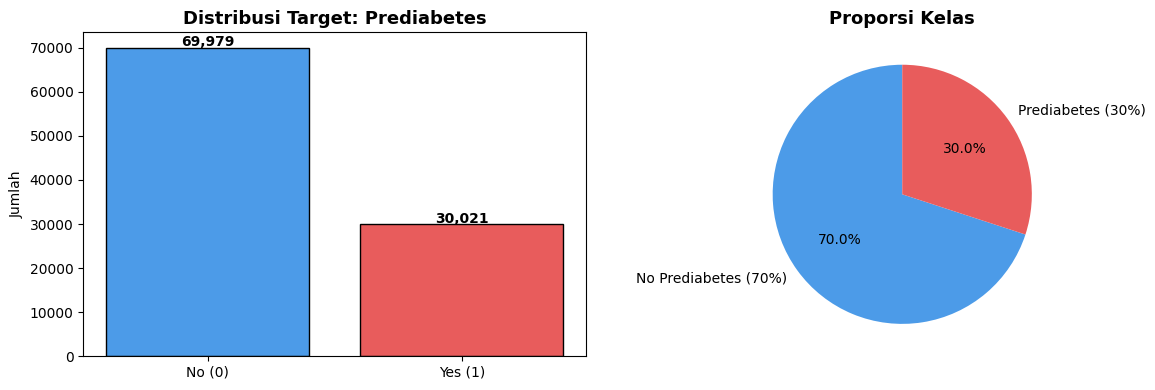

⚠️  Data imbalance: 70% No vs 30% Yes → akan ditangani dengan scale_pos_weight


In [14]:
# Distribusi target label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Prediabetes'].value_counts()
axes[0].bar(['No (0)', 'Yes (1)'], counts.values, color=['#4C9BE8', '#E85C5C'], edgecolor='black')
axes[0].set_title('Distribusi Target: Prediabetes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=['No Prediabetes (70%)', 'Prediabetes (30%)'],
    colors=['#4C9BE8', '#E85C5C'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporsi Kelas', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('⚠️  Data imbalance: 70% No vs 30% Yes → akan ditangani dengan scale_pos_weight')

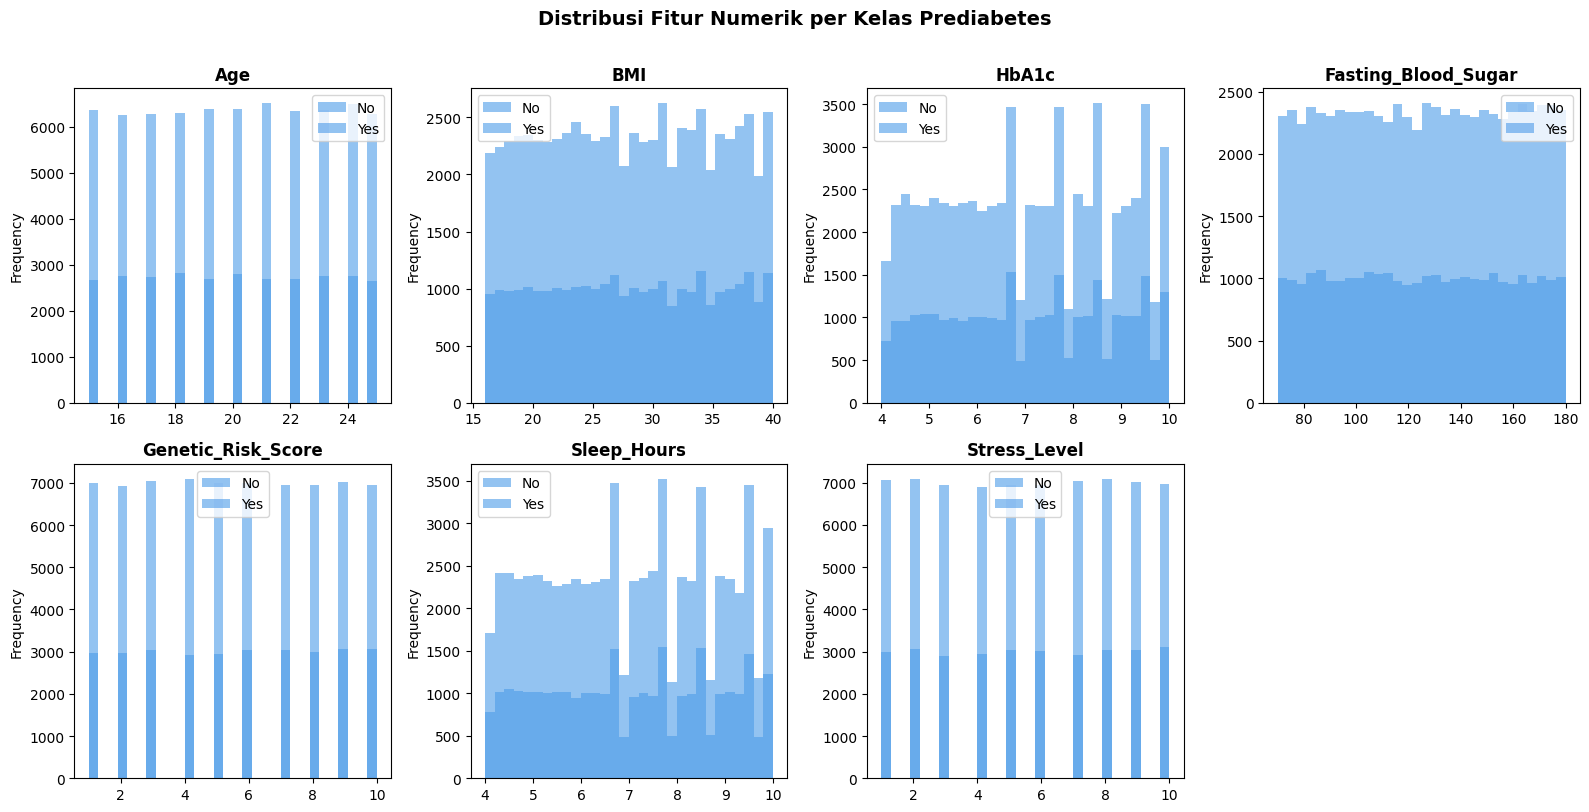

In [15]:
# Distribusi fitur numerik
num_cols = ['Age', 'BMI', 'HbA1c', 'Fasting_Blood_Sugar', 'Genetic_Risk_Score', 'Sleep_Hours', 'Stress_Level']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.groupby('Prediabetes')[col].plot(
        kind='hist', ax=axes[i], alpha=0.6, bins=30,
        color=['#4C9BE8', '#E85C5C'], legend=True
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(['No', 'Yes'])

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik per Kelas Prediabetes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

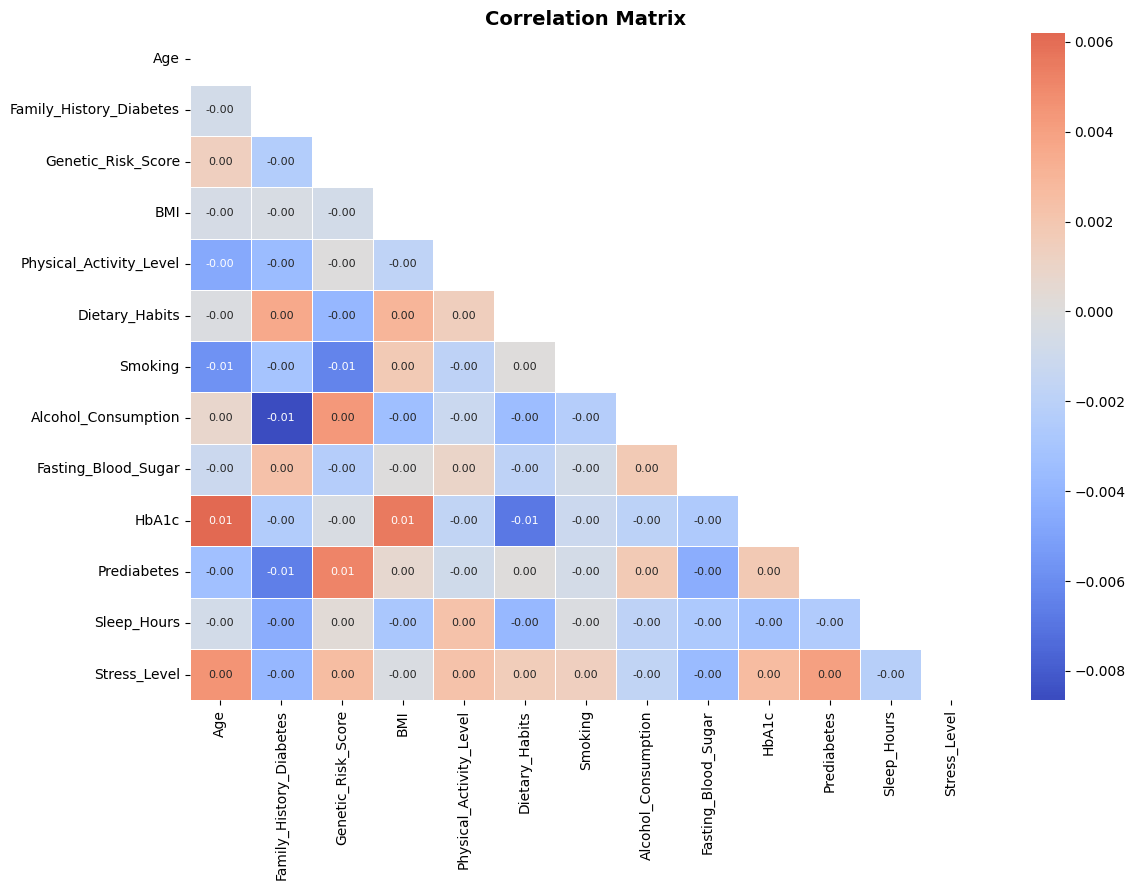

In [16]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## STEP 7 — Split Fitur dan Target

In [17]:
FEATURES = [
    'Age', 'BMI', 'HbA1c', 'Fasting_Blood_Sugar',
    'Genetic_Risk_Score', 'Family_History_Diabetes',
    'Physical_Activity_Level', 'Dietary_Habits',
    'Smoking', 'Alcohol_Consumption',
    'Sleep_Hours', 'Stress_Level'
]
TARGET = 'Prediabetes'

X = df[FEATURES]
y = df[TARGET]

print(f'Shape X (fitur) : {X.shape}')
print(f'Shape y (target): {y.shape}')
print(f'Fitur yang digunakan ({len(FEATURES)}): {FEATURES}')

Shape X (fitur) : (100000, 12)
Shape y (target): (100000,)
Fitur yang digunakan (12): ['Age', 'BMI', 'HbA1c', 'Fasting_Blood_Sugar', 'Genetic_Risk_Score', 'Family_History_Diabetes', 'Physical_Activity_Level', 'Dietary_Habits', 'Smoking', 'Alcohol_Consumption', 'Sleep_Hours', 'Stress_Level']


---
## STEP 8 — Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # pastikan proporsi kelas sama di train dan test
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print()
print('Distribusi kelas di train:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Distribusi kelas di test:')
print(y_test.value_counts(normalize=True).round(3))

X_train shape : (80000, 12)
X_test shape  : (20000, 12)

Distribusi kelas di train:
Prediabetes
0    0.7
1    0.3
Name: proportion, dtype: float64

Distribusi kelas di test:
Prediabetes
0    0.7
1    0.3
Name: proportion, dtype: float64


---
## STEP 8B — Baseline Model Prediabetes

Pada tahap ini ditambahkan baseline model menggunakan `DummyClassifier`. Baseline digunakan sebagai pembanding sederhana untuk mengetahui apakah model machine learning benar-benar memberikan nilai tambah dibanding strategi paling sederhana.

Baseline pada bagian ini selalu memprediksi kelas mayoritas. Jika model machine learning tidak mampu mengalahkan baseline secara bermakna, maka model belum dapat dianggap memiliki performa prediktif yang baik.

Output yang diperhatikan meliputi accuracy, classification report, dan confusion matrix.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))
print(confusion_matrix(y_test, y_pred_base))

Baseline Accuracy: 0.6998
              precision    recall  f1-score   support

           0       0.70      1.00      0.82     13996
           1       0.00      0.00      0.00      6004

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000

[[13996     0]
 [ 6004     0]]


---
## STEP 9 — Hitung scale_pos_weight untuk Imbalance

> **Kenapa `scale_pos_weight`?**  
> Dataset imbalance (70% No vs 30% Yes). Parameter ini memberikan bobot lebih pada kelas minoritas (Prediabetes = Yes) sehingga model tidak bias ke kelas mayoritas.

In [20]:
neg = (y_train == 0).sum()   # jumlah No
pos = (y_train == 1).sum()   # jumlah Yes
spw = neg / pos              # scale_pos_weight

print(f'Jumlah No  (0): {neg:,}')
print(f'Jumlah Yes (1): {pos:,}')
print(f'scale_pos_weight: {spw:.4f}')
print()
print('✅ scale_pos_weight siap digunakan di XGBClassifier!')

Jumlah No  (0): 55,983
Jumlah Yes (1): 24,017
scale_pos_weight: 2.3310

✅ scale_pos_weight siap digunakan di XGBClassifier!


---
## ✅ Preprocessing Selesai!

### Ringkasan hasil preprocessing:

| Item | Nilai |
|---|---|
| Total data | 100,000 baris |
| Fitur final | 12 fitur |
| Target | `Prediabetes` (0/1) |
| Training set | 80,000 baris |
| Test set | 20,000 baris |
| Missing value | 0 |
| Imbalance handling | `scale_pos_weight` |

### Langkah selanjutnya:
1. Training XGBoost dengan `scale_pos_weight`
2. Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)
3. Evaluasi: ROC-AUC, F1-Score, Confusion Matrix
4. Feature Importance analysis

---
## STEP 10 — Training XGBoost untuk Prediabetes

Pada tahap ini dilakukan pelatihan model XGBoost untuk memprediksi target asli `Prediabetes`. Model ini tetap dievaluasi secara hati-hati karena performa model binary sebelumnya menunjukkan indikasi belum cukup kuat.

Hal yang dilakukan pada tahap ini meliputi:
1. Membuat model XGBoost dengan parameter yang sudah ditentukan.
2. Menggunakan `scale_pos_weight` untuk membantu menangani ketidakseimbangan kelas.
3. Melatih model pada data training yang telah dipisahkan sebelumnya.

Model yang dihasilkan pada tahap ini akan dibandingkan dengan baseline dan dievaluasi menggunakan beberapa metrik agar kesimpulan tidak hanya bergantung pada accuracy.

In [21]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=spw,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model.fit(X_train, y_train)
print('✅ Model berhasil ditraining!')

✅ Model berhasil ditraining!


---
## STEP 11 — Evaluasi Model Binary Prediabetes

Pada tahap ini dilakukan evaluasi terhadap model XGBoost binary untuk target asli `Prediabetes`. Evaluasi dilakukan secara objektif dengan memperhatikan bahwa accuracy saja tidak cukup, terutama ketika distribusi kelas tidak seimbang.

Metrik yang digunakan meliputi:
1. Classification Report untuk melihat precision, recall, dan f1-score.
2. ROC-AUC untuk menilai kemampuan model membedakan kelas positif dan negatif.
3. Confusion Matrix untuk melihat pola kesalahan prediksi.
4. PR-AUC yang ditambahkan pada revisi ini karena lebih informatif untuk data imbalance.

Interpretasi hasil perlu dilakukan secara hati-hati. Jika ROC-AUC mendekati 0.5, maka model belum mampu membedakan kelas dengan lebih baik dari tebakan acak.

In [22]:

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification Report
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {auc:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.70      0.55      0.62     13996
         Yes       0.30      0.45      0.36      6004

    accuracy                           0.52     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.58      0.52      0.54     20000

ROC-AUC Score: 0.5018


---
### Tambahan Evaluasi — Precision-Recall AUC

Pada revisi ini ditambahkan metrik PR-AUC atau Precision-Recall AUC untuk evaluasi model binary `Prediabetes`. PR-AUC digunakan karena lebih informatif pada data yang tidak seimbang, terutama ketika fokus evaluasi berada pada kelas minoritas seperti `Prediabetes = Yes`.

Jika nilai PR-AUC rendah, hal tersebut menunjukkan bahwa model masih kesulitan menghasilkan prediksi positif yang presisi sekaligus memiliki recall yang baik.

In [23]:
from sklearn.metrics import average_precision_score

y_proba = model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_proba)
print("PR-AUC:", pr_auc)

PR-AUC: 0.30197401459861456


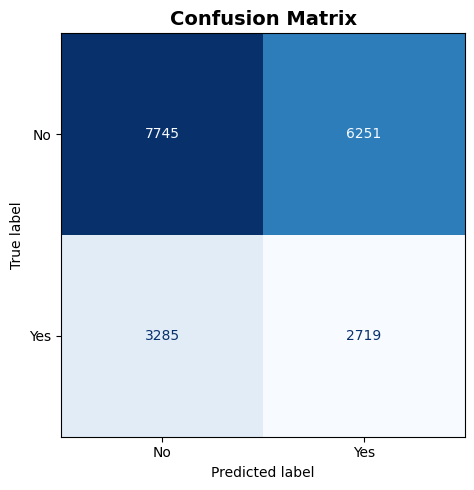

True Negative  (No → No)   : 7,745
False Positive (No → Yes)  : 6,251
False Negative (Yes → No)  : 3,285
True Positive  (Yes → Yes) : 2,719


In [24]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretasi
tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (No → No)   : {tn:,}')
print(f'False Positive (No → Yes)  : {fp:,}')
print(f'False Negative (Yes → No)  : {fn:,}')
print(f'True Positive  (Yes → Yes) : {tp:,}')

# ================================================================

---
### Interpretasi Evaluasi Model Binary Prediabetes

Model binary `Prediabetes` perlu diinterpretasikan secara hati-hati. Jika hasil evaluasi menunjukkan accuracy sekitar 0.52, ROC-AUC mendekati 0.50, dan f1-score untuk kelas `Yes` masih rendah, maka model belum memiliki kemampuan prediktif yang kuat.

Nilai ROC-AUC yang mendekati 0.5 menunjukkan bahwa model hampir tidak mampu membedakan kelas `Prediabetes = Yes` dan `Prediabetes = No` secara lebih baik dari tebakan acak. Selain itu, karena distribusi kelas tidak seimbang, accuracy tidak dapat dijadikan satu-satunya ukuran performa.

Oleh karena itu, metrik seperti precision, recall, f1-score, ROC-AUC, PR-AUC, dan confusion matrix digunakan untuk memberikan gambaran performa yang lebih lengkap.

Kesimpulan sementara dari model binary adalah bahwa fitur yang tersedia belum cukup kuat untuk memprediksi label `Prediabetes` asli secara akurat. Pendekatan tambahan berbasis `Risk_Level` digunakan sebagai sistem klasifikasi risiko, bukan sebagai pengganti diagnosis medis.

---
## STEP 12 — Buat Label Risk_Level sebagai Target Buatan

Pada tahap ini dibuat target baru bernama `Risk_Level` sebagai pendekatan scoring berbasis faktor risiko medis dan lifestyle. Target ini **bukan label asli dari dataset**, melainkan label turunan yang dibuat dari kombinasi beberapa faktor risiko.

Faktor yang digunakan dalam scoring meliputi BMI, HbA1c, Fasting Blood Sugar, Genetic Risk Score, Physical Activity Level, Dietary Habits, Smoking, Stress Level, Sleep Hours, dan Age.

Kategori `Risk_Level` digunakan untuk mengelompokkan pengguna ke dalam tiga tingkat risiko:
1. `Tidak Berisiko`
2. `Sedang`
3. `Tinggi`

Dengan demikian, model pada bagian Risk_Level lebih tepat disebut sebagai sistem klasifikasi risiko berbasis scoring, bukan model diagnosis medis.

In [25]:
# Load ulang dataset bersih (sebelum encoding)
# df_risk = pd.read_csv('diabetes_young_adults_india.csv')
file_path = "../data/diabetes_young_adults_india.csv"
df_risk = pd.read_csv(file_path)

# Drop kolom yang tidak dipakai
cols_to_drop = [
    'ID', 'Gender', 'Region', 'Family_Income',
    'Parent_Diabetes_Type', 'Fast_Food_Intake', 'Cholesterol_Level',
    'Screen_Time', 'Diabetes_Type', 'Prediabetes'
]
df_risk = df_risk.drop(columns=cols_to_drop)

print(f'Shape: {df_risk.shape}')
print(df_risk.head())

Shape: (100000, 12)
   Age Family_History_Diabetes  Genetic_Risk_Score   BMI  \
0   21                      No                   6  31.4   
1   18                      No                   5  24.4   
2   25                      No                   6  20.0   
3   22                      No                   4  39.8   
4   19                      No                   4  19.2   

  Physical_Activity_Level Dietary_Habits Smoking Alcohol_Consumption  \
0               Sedentary       Moderate     Yes                  No   
1                  Active      Unhealthy      No                  No   
2                Moderate       Moderate      No                  No   
3                Moderate      Unhealthy      No                 Yes   
4                Moderate       Moderate      No                 Yes   

   Fasting_Blood_Sugar  HbA1c  Sleep_Hours  Stress_Level  
0                 95.6    9.5          7.7             7  
1                164.9    5.0          7.9             8  
2        

---
### Catatan Metodologis tentang Risk_Level

`Risk_Level` merupakan target buatan yang dibuat berdasarkan sistem scoring dari beberapa faktor risiko, seperti BMI, HbA1c, Fasting Blood Sugar, Genetic Risk Score, Physical Activity Level, Dietary Habits, Smoking, Stress Level, Sleep Hours, dan Age.

Target ini bukan label asli dari dataset. Oleh karena itu, model `Risk_Level` tidak dapat diklaim sebagai model diagnosis medis, melainkan sebagai sistem klasifikasi risiko berbasis scoring yang bertujuan membantu mengelompokkan pengguna ke dalam kategori `Tidak Berisiko`, `Sedang`, dan `Tinggi`.

Model XGBoost pada bagian ini berperan untuk mempelajari pola dari sistem scoring tersebut agar dapat digunakan dalam aplikasi prediksi risiko.

---
## STEP 13 — Fungsi Scoring Risk_Level

Pada tahap ini didefinisikan fungsi scoring untuk membentuk label `Risk_Level`. Fungsi ini menghitung skor berdasarkan faktor genetik, klinis, dan gaya hidup, lalu mengubah total skor menjadi kategori risiko.

Tahap ini penting karena kualitas target `Risk_Level` sepenuhnya bergantung pada aturan scoring yang dibuat. Oleh karena itu, hasil model Risk_Level harus diinterpretasikan sebagai hasil pembelajaran terhadap aturan scoring, bukan sebagai pembuktian adanya diagnosis diabetes.

In [26]:


def create_risk_level(row):
    score = 0

    # Faktor Genetik
    if row['Genetic_Risk_Score'] >= 8: score += 3
    elif row['Genetic_Risk_Score'] >= 5: score += 2
    else: score += 1

    if row['Family_History_Diabetes'] == 'Yes': score += 2

    # Faktor Klinis
    if row['BMI'] >= 30: score += 3
    elif row['BMI'] >= 25: score += 2
    else: score += 0

    if row['HbA1c'] >= 6.5: score += 3
    elif row['HbA1c'] >= 5.7: score += 2
    else: score += 0

    if row['Fasting_Blood_Sugar'] >= 126: score += 3
    elif row['Fasting_Blood_Sugar'] >= 100: score += 2
    else: score += 0

    # Faktor Gaya Hidup
    if row['Physical_Activity_Level'] == 'Sedentary': score += 2
    elif row['Physical_Activity_Level'] == 'Moderate': score += 1

    if row['Dietary_Habits'] == 'Unhealthy': score += 2
    elif row['Dietary_Habits'] == 'Moderate': score += 1

    if row['Smoking'] == 'Yes': score += 1
    if row['Alcohol_Consumption'] == 'Yes': score += 1
    if row['Stress_Level'] >= 8: score += 1
    if row['Sleep_Hours'] <= 5: score += 1
    if row['Age'] >= 22: score += 1

    # Threshold (max score ~21)
    if score >= 14: return 'Tinggi'
    elif score >= 8: return 'Sedang'
    else: return 'Tidak Berisiko'

df_risk['Risk_Level'] = df_risk.apply(create_risk_level, axis=1)
print('Distribusi Risk_Level:')
print(df_risk['Risk_Level'].value_counts())

Distribusi Risk_Level:
Risk_Level
Sedang            61961
Tinggi            30751
Tidak Berisiko     7288
Name: count, dtype: int64


# STEP 14 — Encoding untuk Risk_Level approach

In [27]:


# Binary encoding
binary_cols = ['Family_History_Diabetes', 'Smoking', 'Alcohol_Consumption']
for col in binary_cols:
    df_risk[col] = df_risk[col].map({'Yes': 1, 'No': 0})

# Ordinal encoding
df_risk['Physical_Activity_Level'] = df_risk['Physical_Activity_Level'].map(
    {'Sedentary': 0, 'Moderate': 1, 'Active': 2}
)
df_risk['Dietary_Habits'] = df_risk['Dietary_Habits'].map(
    {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
)

# Encoding target Risk_Level
df_risk['Risk_Level'] = df_risk['Risk_Level'].map(
    {'Tidak Berisiko': 0, 'Sedang': 1, 'Tinggi': 2}
)

print('✅ Encoding selesai!')
print(df_risk['Risk_Level'].value_counts())

✅ Encoding selesai!
Risk_Level
1    61961
2    30751
0     7288
Name: count, dtype: int64


---
## STEP 15 — Split Data Risk_Level dan SMOTE

Pada tahap ini data `Risk_Level` dibagi menjadi data training dan testing, kemudian SMOTE diterapkan pada data training untuk menyeimbangkan distribusi kelas.

SMOTE digunakan agar model tidak terlalu bias terhadap kelas mayoritas. Namun, SMOTE hanya boleh diterapkan pada data training setelah train-test split. Data testing tidak boleh di-SMOTE agar evaluasi tetap mencerminkan distribusi data asli.

Catatan metodologis: untuk cross validation, SMOTE sebaiknya ditempatkan di dalam pipeline agar proses oversampling hanya terjadi pada fold training dan tidak menyebabkan data leakage.

In [28]:
from imblearn.over_sampling import SMOTE

# Split fitur dan target
X_risk = df_risk.drop(columns=['Risk_Level'])
y_risk = df_risk['Risk_Level']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_risk, y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

print('Sebelum SMOTE:')
print(y_train_r.value_counts())

# SMOTE
sm = SMOTE(random_state=42)
X_train_r, y_train_r = sm.fit_resample(X_train_r, y_train_r)

print()
print('Setelah SMOTE:')
print(y_train_r.value_counts())

Sebelum SMOTE:
Risk_Level
1    49569
2    24601
0     5830
Name: count, dtype: int64

Setelah SMOTE:
Risk_Level
2    49569
0    49569
1    49569
Name: count, dtype: int64


# STEP 16 — Training XGBoost dengan Risk_Level

In [29]:


model_risk = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',  # multiclass
    verbosity=0
)

model_risk.fit(X_train_r, y_train_r)
print('✅ Model berhasil ditraining!')

✅ Model berhasil ditraining!


---
## STEP 16B — Cross Validation XGBoost Risk Level

Pada bagian awal step ini, cross validation masih dilakukan pada data training yang sudah di-SMOTE. Pendekatan tersebut dapat menghasilkan estimasi performa yang terlalu optimis karena data sintetis sudah dibuat sebelum proses pembagian fold.

Untuk memperbaiki hal tersebut, notebook ini menambahkan pendekatan cross validation yang lebih tepat menggunakan `imblearn.pipeline.Pipeline`. Dengan pipeline, SMOTE diterapkan hanya pada fold training di setiap iterasi cross validation.

Cross validation digunakan untuk menguji kestabilan performa model pada beberapa fold data, sehingga hasil evaluasi tidak hanya bergantung pada satu pembagian train-test split.

In [30]:


from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model_risk,
    X_train_r, y_train_r,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print('=== Hasil Cross Validation (5-Fold) ===')
for i, score in enumerate(cv_scores):
    print(f'Fold {i+1}: {score:.4f}')
print()
print(f'Mean Accuracy : {cv_scores.mean():.4f}')
print(f'Std           : {cv_scores.std():.4f}')
print(f'Min           : {cv_scores.min():.4f}')
print(f'Max           : {cv_scores.max():.4f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


=== Hasil Cross Validation (5-Fold) ===
Fold 1: 0.9522
Fold 2: 0.9532
Fold 3: 0.9526
Fold 4: 0.9509
Fold 5: 0.9517

Mean Accuracy : 0.9521
Std           : 0.0008
Min           : 0.9509
Max           : 0.9532


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   18.6s finished


---
### Cross Validation yang Diperbaiki dengan Pipeline SMOTE

Pada revisi ini ditambahkan cross validation yang lebih aman menggunakan `imblearn.pipeline.Pipeline`. SMOTE ditempatkan di dalam pipeline cross validation untuk mencegah data leakage.

Jika SMOTE dilakukan sebelum cross validation, data sintetis yang mirip dapat tersebar ke beberapa fold dan menyebabkan hasil evaluasi terlalu optimis. Dengan pipeline, SMOTE hanya diterapkan pada data training di masing-masing fold, sedangkan fold validasi tetap berisi data asli.

Hasil cross validation dari cell berikut lebih layak digunakan sebagai estimasi kestabilan model dibanding cross validation pada data yang sudah di-SMOTE sebelumnya.

In [31]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

pipeline_smote_xgb = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_pipeline = cross_val_score(
    pipeline_smote_xgb,
    X_risk,
    y_risk,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores_pipeline)
print("Mean CV Accuracy:", cv_scores_pipeline.mean())
print("Std CV Accuracy:", cv_scores_pipeline.std())

Cross Validation Scores: [0.9688  0.9662  0.96915 0.9674  0.96825]
Mean CV Accuracy: 0.96796
Std CV Accuracy: 0.001059905656178894


---
## STEP 17 — Evaluasi Model Risk_Level

Pada tahap ini dilakukan evaluasi terhadap model XGBoost yang memprediksi `Risk_Level`. Evaluasi ini digunakan untuk melihat seberapa baik model mempelajari kategori risiko yang dibentuk dari sistem scoring.

Metrik dan output yang digunakan meliputi:
1. Classification Report untuk melihat precision, recall, dan f1-score pada setiap kelas risiko.
2. Confusion Matrix untuk melihat pola kesalahan prediksi antar kategori `Tidak Berisiko`, `Sedang`, dan `Tinggi`.
3. Interpretasi hasil dengan tetap menekankan bahwa `Risk_Level` adalah target buatan berbasis scoring.

Hasil evaluasi pada bagian ini tidak boleh disamakan dengan kemampuan diagnosis medis, melainkan sebagai evaluasi sistem klasifikasi risiko.

=== Classification Report ===
                precision    recall  f1-score   support

Tidak Berisiko       0.75      0.95      0.84      1458
        Sedang       0.98      0.91      0.94     12392
        Tinggi       0.90      0.97      0.94      6150

      accuracy                           0.93     20000
     macro avg       0.88      0.94      0.91     20000
  weighted avg       0.94      0.93      0.93     20000



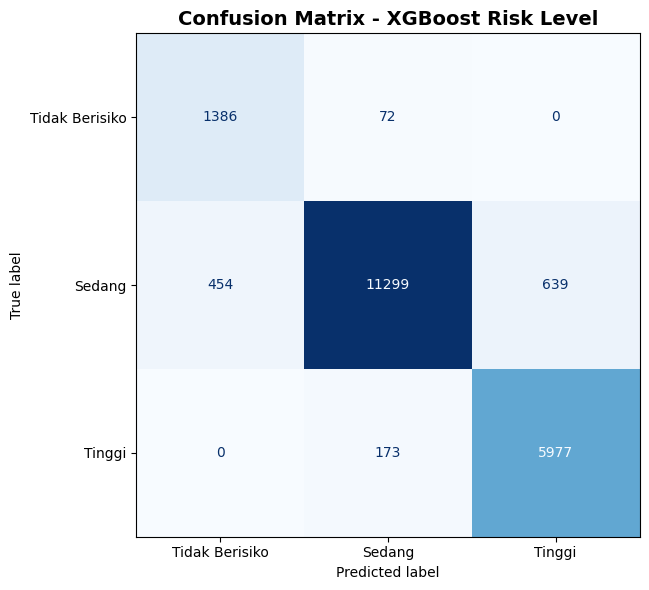

In [32]:
y_pred_r = model_risk.predict(X_test_r)

# Classification Report
print('=== Classification Report ===')
print(classification_report(
    y_test_r, y_pred_r,
    target_names=['Tidak Berisiko', 'Sedang', 'Tinggi']
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm_r = confusion_matrix(y_test_r, y_pred_r)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_r,
    display_labels=['Tidak Berisiko', 'Sedang', 'Tinggi']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - XGBoost Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## STEP 18 — Feature Importance

Pada tahap ini dilakukan analisis feature importance untuk melihat fitur mana yang paling berpengaruh terhadap prediksi `Risk_Level`. Analisis ini membantu memahami faktor yang paling banyak digunakan model ketika meniru pola dari sistem scoring.

Feature importance perlu diinterpretasikan dengan konteks yang tepat. Karena `Risk_Level` adalah target buatan berbasis scoring, fitur yang penting menunjukkan pengaruh terhadap aturan risiko yang dibuat, bukan bukti kausal atau diagnosis medis.

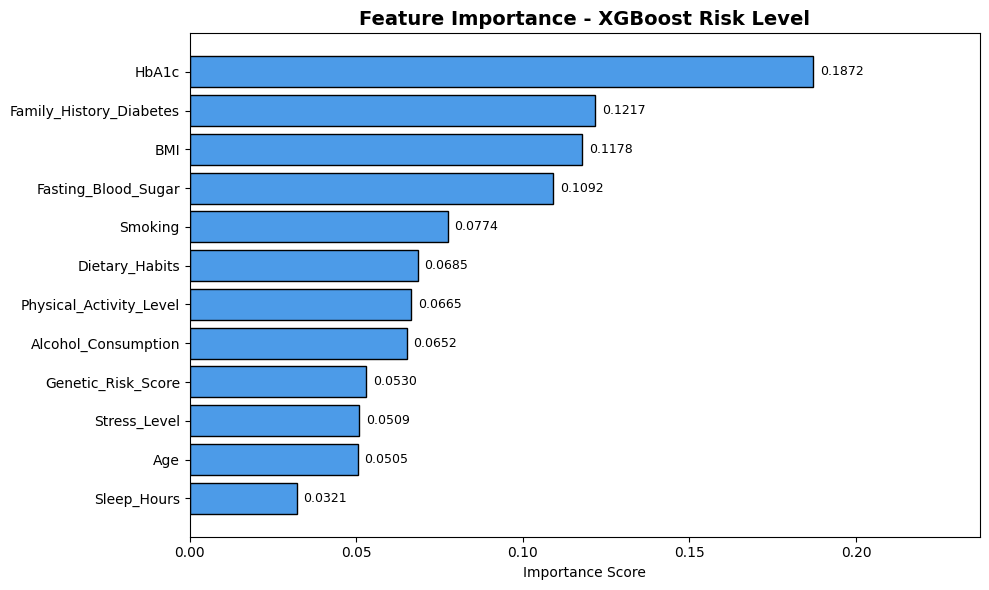

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil feature importance
importance = model_risk.feature_importances_
feature_names = X_risk.columns.tolist()

# Sort descending
indices = np.argsort(importance)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importance = importance[indices]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_features[::-1], sorted_importance[::-1], color='#4C9BE8', edgecolor='black')

# Tambah nilai di tiap bar
for bar, val in zip(bars, sorted_importance[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Feature Importance - XGBoost Risk Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, max(sorted_importance) + 0.05)
plt.tight_layout()
plt.show()

---
## Penyimpanan Model

Pada tahap ini, model `Risk_Level` yang telah dilatih disimpan menggunakan joblib. Penyimpanan model dilakukan agar model dapat digunakan kembali tanpa perlu melakukan proses training ulang.

Selain model, komponen pendukung seperti mapping label target, mapping fitur kategorikal, dan daftar kolom fitur juga disimpan. Hal ini penting agar proses prediksi di tahap berikutnya menggunakan struktur input yang sama seperti saat model dilatih.

File yang disimpan pada tahap ini meliputi:
1. Model XGBoost Risk_Level.
2. Mapping label Risk_Level dari label teks ke angka.
3. Mapping inverse Risk_Level dari angka ke label teks.
4. Daftar kolom fitur training.
5. Mapping encoding fitur kategorikal yang digunakan pada notebook.

Cell ini tidak membuat aplikasi apa pun dan hanya berfokus pada penyimpanan model serta komponen pendukung.

In [36]:
import os
import joblib

model_path = "../models"
os.makedirs(model_path, exist_ok=True)

# Mapping target Risk_Level yang digunakan pada STEP 14
risk_level_mapping = {
    'Tidak Berisiko': 0,
    'Sedang': 1,
    'Tinggi': 2
}
risk_level_inverse_mapping = {v: k for k, v in risk_level_mapping.items()}

# Mapping fitur kategorikal yang digunakan pada proses encoding manual
feature_encoding_mapping = {
    'Family_History_Diabetes': {'Yes': 1, 'No': 0},
    'Smoking': {'Yes': 1, 'No': 0},
    'Alcohol_Consumption': {'Yes': 1, 'No': 0},
    'Physical_Activity_Level': {'Sedentary': 0, 'Moderate': 1, 'Active': 2},
    'Dietary_Habits': {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
}

# Daftar kolom fitur yang digunakan saat training Risk_Level
feature_columns_risk = X_risk.columns.tolist()

# Simpan model Risk_Level dan komponen pendukung
joblib.dump(model_risk, f"{model_path}/xgboost_risk_level_model.pkl")
joblib.dump(risk_level_mapping, f"{model_path}/risk_level_mapping.pkl")
joblib.dump(risk_level_inverse_mapping, f"{model_path}/risk_level_inverse_mapping.pkl")
joblib.dump(feature_columns_risk, f"{model_path}/feature_columns.pkl")
joblib.dump(feature_encoding_mapping, f"{model_path}/feature_encoding_mapping.pkl")

print("Model dan komponen pendukung berhasil disimpan.")
print(f"File tersimpan di folder {model_path}")
print("1. xgboost_risk_level_model.pkl")
print("2. risk_level_mapping.pkl")
print("3. risk_level_inverse_mapping.pkl")
print("4. feature_columns.pkl")
print("5. feature_encoding_mapping.pkl")

Model dan komponen pendukung berhasil disimpan.
File tersimpan di folder ../models
1. xgboost_risk_level_model.pkl
2. risk_level_mapping.pkl
3. risk_level_inverse_mapping.pkl
4. feature_columns.pkl
5. feature_encoding_mapping.pkl


---
## Perbedaan Pendekatan Model

Notebook ini menggunakan dua pendekatan utama yang harus dibedakan secara jelas.

1. **Model Prediabetes asli**

Model ini menggunakan target asli dari dataset, yaitu `Prediabetes = Yes` atau `Prediabetes = No`. Hasil evaluasi menunjukkan bahwa performa model masih rendah, terutama jika ROC-AUC berada mendekati 0.5. Oleh karena itu, model ini belum dapat digunakan sebagai prediktor utama yang akurat.

2. **Model Risk_Level**

Model ini menggunakan target buatan berbasis sistem scoring faktor risiko. Hasil performanya dapat terlihat lebih tinggi karena model belajar dari aturan scoring yang telah dibuat. Oleh karena itu, model ini lebih tepat disebut sebagai sistem klasifikasi risiko, bukan model diagnosis medis.

Dengan demikian, pendekatan `Risk_Level` lebih sesuai untuk digunakan sebagai alat screening awal dan edukasi risiko, bukan sebagai pengganti pemeriksaan medis.

---
## Keterbatasan Metodologi

Beberapa keterbatasan penting dari notebook ini adalah sebagai berikut:

1. Label `Prediabetes` asli belum dapat diprediksi dengan kuat menggunakan fitur yang tersedia, ditunjukkan oleh ROC-AUC yang mendekati tebakan acak.
2. `Risk_Level` adalah target buatan berbasis scoring, sehingga performa model pada bagian tersebut tidak dapat disamakan dengan performa diagnosis klinis.
3. SMOTE dapat membantu balancing, tetapi tidak menambah informasi klinis baru ke dataset.
4. Evaluasi internal belum cukup untuk menyatakan model generalizable ke populasi lain.
5. Model perlu diuji pada data eksternal dan dibandingkan dengan algoritma lain sebelum digunakan dalam konteks yang lebih luas.

Keterbatasan ini penting agar hasil notebook tidak ditafsirkan secara berlebihan.

---
## Kesimpulan Akhir

Berdasarkan hasil eksperimen, model XGBoost untuk memprediksi label `Prediabetes` asli belum menunjukkan performa yang optimal. Nilai ROC-AUC yang mendekati 0.5 menunjukkan bahwa model belum mampu membedakan kelas Prediabetes dan Non-Prediabetes dengan baik.

Sebagai pendekatan tambahan, dibuat sistem `Risk_Level` berbasis scoring faktor risiko. Pendekatan ini menghasilkan performa yang lebih stabil karena target `Risk_Level` dibangun dari kombinasi faktor klinis dan gaya hidup. Namun, karena `Risk_Level` merupakan target buatan, hasil model ini harus diinterpretasikan sebagai klasifikasi risiko, bukan diagnosis medis.

Untuk pengembangan selanjutnya, model dapat ditingkatkan dengan:
1. Menggunakan dataset dengan label klinis yang lebih kuat.
2. Melakukan hyperparameter tuning.
3. Menggunakan pipeline validasi yang mencegah data leakage.
4. Membandingkan beberapa algoritma machine learning.
5. Menguji model pada data eksternal.